# GISLR — Continuous-signing models: per-frame gloss + null + sign-boundary

**What this notebook does.** Pipeline stage (training), TODO §12.3. It trains
models on **continuous multi-sign streams** instead of isolated clips. At
every frame the model outputs a confidence over every gloss plus **null**
(non-signing), and a **sign-boundary** probability ("the sign in progress
has just ended").

**Why.** The §12.2 baselines (`docs/reports/sentence-baselines.md`) showed
that today's isolated models lose most of their accuracy on continuous
signing through *missed* signs. A fixed "confident for N frames" rule
cannot find the end of both short and long signs: 60% correct even with a
perfect reset, vs 76% isolated. So the model is trained (a) per frame, so
confidence is meaningful throughout a sign, and (b) to signal the boundary
itself.

**Runs** (`experiments/recognition/configs/gislr.continuous.json`, one section each):

| run | arch | what it tests |
|---|---|---|
| **C1** | `gru_continuous` | the main model: per-frame gloss+null CE + boundary BCE, all 250 glosses |
| **C2** | `lstm_continuous` | the same with an LSTM body |
| **C3** | `gru_continuous`, `loss: ctc` | alignment-free CTC (blank = null): what real continuous video would need |
| **Copen** | `gru_continuous`, 20 glosses held out | the model TODO §12.4 teaches new signs to (held-out glosses masked in the cosine head) |

Model: `sb.recognize.architectures.ContinuousRNN`, a 2×256 causal GRU/LSTM on
ME-132 xy (the best registry configuration). It has a **cosine** gloss head,
so a new sign can later be added from the mean embedding of a few examples
without retraining. It keeps the standard isolated read-out, so
`sb-evaluate` scores it canonically (§8).

**Training data** (`sb.recognize.continuous.data`). Every epoch is a new
random partition of `train.csv`'s clips into one-signer, random-order streams
of 1–6 signs:
- 0–15 interpolated gap frames between signs (0 = back-to-back);
- 5–30 rest frames at each end, of two kinds:
  - 70% **lowered**: the pose wrists drop to hip height and each hand
    disappears (NaN) once its wrist leaves the frame. This is how MediaPipe
    sees a resting signer in these selfie-framed videos: hips are out of
    frame in 97% of training frames, and hands are never detected below
    y ≈ 0.9;
  - 30% hands-absent with the pose left at signing height, GISLR-Sentences
    v1's rest;
- clips at **native length** (no 128-frame subsampling).

A sign-stratified 5% of `train.csv` becomes fixed validation streams.
Checkpoints are selected on their **segment accuracy**. `test.csv` and
GISLR-Sentences are never used for selection.

**Artifacts**

| path | content |
|---|---|
| `registry/runs/<run_id>/` | one registry run per training (meta.json every epoch, `best.pt`/`last.pt`, `assets/history.json`) |
| `data/cache/gislr/features/clipbank_v1/<key>/train_{data,offsets}.npy` | NaN-preserving `train.csv` clip bank, ~3 GB, content-addressed |
| `data/cache/gislr/continuous/assets/*.png` | composer preview, learning curves |

**Resumable.** Every run auto-resumes from `last.pt` through its pointer file.
A finished run is never reused; re-running a section after it finishes
starts a new run. Each epoch's stream partition is seeded by the epoch
number, so a resumed epoch sees the same data.

**Evaluation on continuous signing** is not here. It is
`gislr.3.streaming.continuous-eval.ipynb`, which uses the same protocol as
the baselines.

**C1 v2 (2026-09-26, TODO §12.8 Fix 3):** §6b trains **C4** (stream normalization + v2 augmented streams) and **C5** (the same streams, C1's raw input) in parallel.

## Setup

In [1]:
# ============================================================
# Imports, config, paths
# ============================================================
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sb.core.paths import CACHE_DIR
from sb.core.subsets import get_subset
from sb.recognize.continuous import data as CD
from sb.recognize.continuous.train import CONFIG_PATH, load_config, run_dir_for, run_hyp, train_continuous
from sb.recognize.sources import get_source

CONFIG = load_config(CONFIG_PATH)
ASSETS = CACHE_DIR / "gislr" / "continuous" / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)

print(f"config: {CONFIG_PATH.name} · regime {CONFIG['regime']} · {CONFIG['subset']}/{CONFIG['coords']}")
for name, run in CONFIG["runs"].items():
    over = {k: v for k, v in run_hyp(CONFIG, name).items() if CONFIG["shared"].get(k) != v}
    print(f"  {name:<6} {run['arch']:<16} overrides {over or '-'}  held-out glosses {run.get('n_holdout_glosses', 0)}"
          f"  run dir {run_dir_for(name) or '(not started)'}")
print(f"cuda: {torch.cuda.is_available()}")

config: gislr.continuous.json · regime continuous-v1 · ME_132/xy
  C1     gru_continuous   overrides -  held-out glosses 0  run dir C:\Users\user2\repository\registry\runs\1790143122
  C2     lstm_continuous  overrides -  held-out glosses 0  run dir C:\Users\user2\repository\registry\runs\1790144582
  C3     gru_continuous   overrides {'loss': 'ctc'}  held-out glosses 0  run dir C:\Users\user2\repository\registry\runs\1790142624
  Copen  gru_continuous   overrides -  held-out glosses 20  run dir C:\Users\user2\repository\registry\runs\1790146838
  C4     gru_continuous_norm overrides -  held-out glosses 0  run dir (not started)
  C5     gru_continuous   overrides -  held-out glosses 0  run dir (not started)
  P1     gru_continuous_phono130 overrides -  held-out glosses 0  run dir C:\Users\user2\repository\registry\runs\1790416771
cuda: True


## 1. Clip bank + composer preview

The first run builds the NaN-preserving `train.csv` clip bank (~1 min, ~3 GB);
after that it is a cache hit. Two example streams are drawn, one per rest
kind, and plotted with their per-frame targets. This is to check the
composer by eye, not a statistic.

clip bank: 75581 clips, 2,864,425 frames x 264 features (3.02 GB)


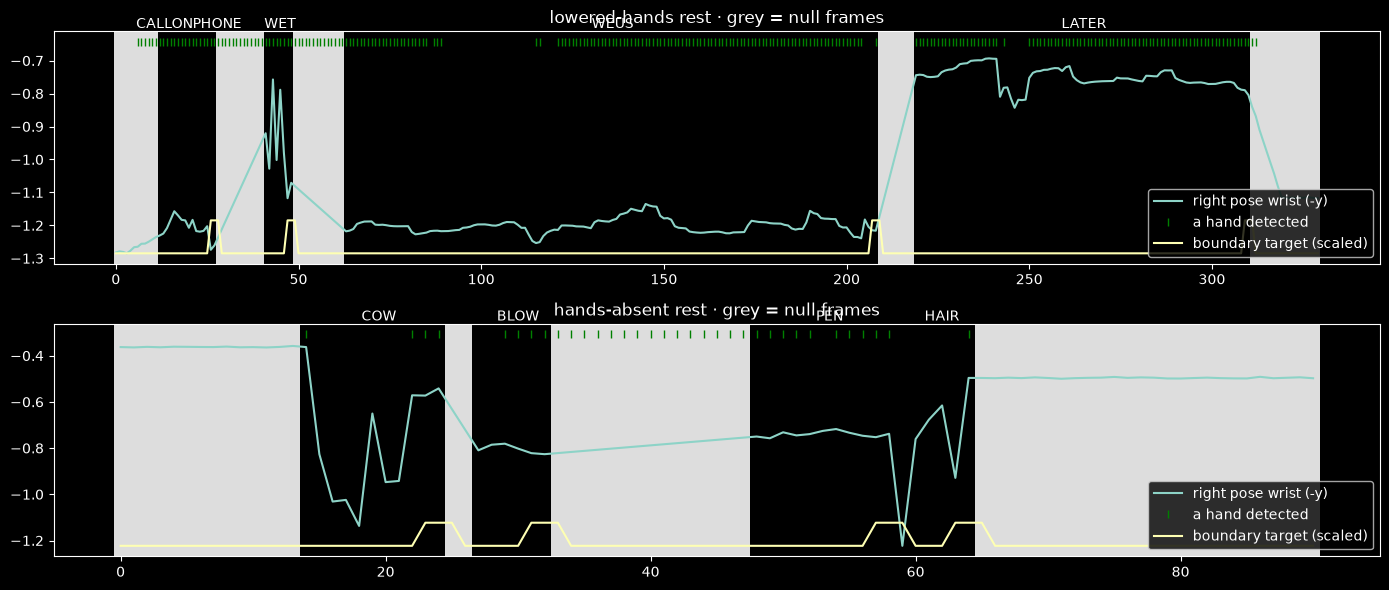

In [2]:
# ============================================================
# Build/load the clip bank, preview two composed streams
# ============================================================
PREVIEW_SEED = 7

ds = get_source(CONFIG["dataset"])
data_dir = ds.resolve_dir()
sign2idx = ds.label_map(data_dir)
idx2sign = {v: k for k, v in sign2idx.items()}
train_split, _ = ds.canonical_split(data_dir, sign2idx)
subset = get_subset(CONFIG["subset"])
bank = CD.ClipBank.build(train_split, "train", subset, CONFIG["coords"], data_dir)
lay = CD.Layout.of(subset.array, CONFIG["coords"])
null_index = len(sign2idx)
print(f"clip bank: {len(bank)} clips, {bank.data.shape[0]:,} frames x {bank.data.shape[1]} features "
      f"({bank.data.nbytes / 1e9:.2f} GB)")

rng = np.random.default_rng(PREVIEW_SEED)
labels = train_split["label"].to_numpy()
pid = train_split["participant_id"].to_numpy()
wrist_col = {int(r): i for i, r in enumerate(subset.array)}[489 + 16] * 2 + 1  # right pose wrist, y
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
for ax, lowered in zip(axes, (1.0, 0.0)):
    who = rng.choice(np.unique(pid))
    clips = rng.choice(np.flatnonzero(pid == who), 4, replace=False)
    s = CD.compose([bank.clip(c) for c in clips], [int(labels[c]) for c in clips], null_index, lay,
                   {**CONFIG["composer"], "p_lowered_rest": lowered}, rng)
    ax.plot(-s["x"][:, wrist_col], label="right pose wrist (-y)")
    hand_present = np.isfinite(s["x"][:, lay.hand_cols[1][0]]) | np.isfinite(s["x"][:, lay.hand_cols[0][0]])
    ax.plot(np.where(hand_present, np.nanmax(-s["x"][:, wrist_col]) + 0.05, np.nan), "g|", label="a hand detected")
    ax.plot(s["b"] * 0.1 + np.nanmin(-s["x"][:, wrist_col]), label="boundary target (scaled)")
    for t in np.flatnonzero(s["y"] == null_index):
        ax.axvspan(t - 0.5, t + 0.5, color="#dddddd", lw=0)
    for (a, b), c in zip(s["segments"], clips):
        ax.text((a + b) / 2, ax.get_ylim()[1], idx2sign[int(labels[c])].upper(), ha="center", va="bottom")
    ax.set_title(f"{'lowered-hands' if lowered else 'hands-absent'} rest · grey = null frames")
    ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(ASSETS / "composer_preview.png", dpi=110)
plt.show()

## 2. Wiring check (seconds; writes nothing)

A few training batches and a short validation pass per run through the
real driver, with no registry folder and no pointer. It catches a broken
config before hours of training.

In [3]:
# ============================================================
# Smoke every run: a few batches, no files written
# ============================================================
SMOKE_BATCHES = 3

for name in CONFIG["runs"]:
    r = train_continuous(name, smoke=SMOKE_BATCHES)
    print(f"{name:<6} params {r['n_params']:,} · train clips {r['n_train_clips']} "
          f"({r['n_train_sequences']} streams/epoch) · val streams {r['n_val_sequences']} · "
          f"held out {len(r['held_out'])} · first/last loss {r['train_losses'][0][0]:.3f} -> "
          f"{r['train_losses'][-1][0]:.3f}")

clip bank (train.csv):   0%|          | 0/75581 [00:00<?, ?it/s]

C1     params 927,505 · train clips 71801 (20493 streams/epoch) · val streams 1097 · held out 0 · first/last loss 7.140 -> 6.024


clip bank (train.csv):   0%|          | 0/75581 [00:00<?, ?it/s]

C2     params 1,192,721 · train clips 71801 (20493 streams/epoch) · val streams 1097 · held out 0 · first/last loss 7.091 -> 5.990


clip bank (train.csv):   0%|          | 0/75581 [00:00<?, ?it/s]

...

Copen  params 927,505 · train clips 66096 (18807 streams/epoch) · val streams 1025 · held out 20 · first/last loss 6.883 -> 5.877


clip bank (train.csv):   0%|          | 0/75581 [00:00<?, ?it/s]

C4     params 929,045 · train clips 71801 (8484 streams/epoch) · val streams 455 · held out 0 · first/last loss 6.536 -> 7.839


clip bank (train.csv):   0%|          | 0/75581 [00:00<?, ?it/s]

C5     params 927,505 · train clips 71801 (8484 streams/epoch) · val streams 455 · held out 0 · first/last loss 7.284 -> 6.952
P1     params 824,325 · train clips 71801 (20493 streams/epoch) · val streams 1097 · held out 0 · first/last loss 6.773 -> 5.497


## 3. C1: GRU, per-frame + boundary (main model)

The model the continuous evaluation centers on. Auto-resumes if interrupted.

In [4]:
# ============================================================
# Train C1
# ============================================================
run_dir = train_continuous("C1")

clip bank (train.csv):   0%|          | 0/75581 [00:00<?, ?it/s]

gislr/gru_continuous/me132-xy/C1 · run 1790429419:   0%|          | 0/150 [00:00<?, ?it/s]

C1: EARLY STOP at epoch 95
C1: DONE best val segment accuracy 0.7233 run_dir=C:\Users\user2\repository\registry\runs\1790429419


## 4. C2: LSTM body

C1 with `lstm_continuous`; everything else identical. Auto-resumes if interrupted.

In [5]:
# ============================================================
# Train C2
# ============================================================
run_dir = train_continuous("C2")

clip bank (train.csv):   0%|          | 0/75581 [00:00<?, ?it/s]

gislr/lstm_continuous/me132-xy/C2 · run 1790430959:   0%|          | 0/150 [00:00<?, ?it/s]

C2: EARLY STOP at epoch 79
C2: DONE best val segment accuracy 0.7103 run_dir=C:\Users\user2\repository\registry\runs\1790430959


## 5. C3: CTC

Trained with CTC (blank = null): no frame alignment used. Its boundary head receives no loss, so decode it with greedy CTC (D4) or null-gated commits (D3). Auto-resumes if interrupted.

In [6]:
# ============================================================
# Train C3
# ============================================================
run_dir = train_continuous("C3")

clip bank (train.csv):   0%|          | 0/75581 [00:00<?, ?it/s]

gislr/gru_continuous/me132-xy/C3 · run 1790432253:   0%|          | 0/150 [00:00<?, ?it/s]

C3: EARLY STOP at epoch 85
C3: DONE best val segment accuracy 0.4934 run_dir=C:\Users\user2\repository\registry\runs\1790432253


## 6. C-open: 20 glosses held out (for §12.4)

C1's recipe with 20 seeded glosses removed from training entirely and masked in the head. Its canonical isolated accuracy on those 20 is 0 by construction until §12.4 enrolls them. Auto-resumes if interrupted.

In [7]:
# ============================================================
# Train Copen
# ============================================================
run_dir = train_continuous("Copen")

clip bank (train.csv):   0%|          | 0/75581 [00:00<?, ?it/s]

gislr/gru_continuous/me132-xy/Copen · run 1790433679:   0%|          | 0/150 [00:00<?, ?it/s]

Copen: EARLY STOP at epoch 95
Copen: DONE best val segment accuracy 0.7243 run_dir=C:\Users\user2\repository\registry\runs\1790433679


## 6b. C1 v2: C4 and C5, trained in parallel (TODO §12.8 Fix 3)

C1 breaks on a live camera: low fps loses signs, jitter and long sessions add signs, framing and mirroring
break it outright (`docs/reports/live-streaming-gap.md`), and real signing runs signs together (hard-cut GER
0.546). v2 attacks each measured failure in training instead of in the app:

- **C4** = `gru_continuous_norm`: C1's GRU behind a fixed per-frame normalization (hands re-slotted by the
  pose wrists, shoulder-centred, shoulder-width scaled), same raw input as C1, so the web app feeds it unchanged;
- **C5** = `gru_continuous` (C1's raw input) on the same v2 streams: the ablation that says whether the
  normalization or the augmentation did the work.

Both train on v2 streams (`composer_overrides` in the config; `sb.recognize.continuous.augment`): clip trim
and speed-up (co-articulation), 25% hard-cut streams, noise blocks labelled null, up to 16 signs / 1,500
frames, and camera augmentation (scale, aspect, rotation, shift, mirror, jitter, hand dropout, 15/10 fps).

Both start together, one process each, output in `data/temp/continuous_train_<run>.log`. Auto-resume:
re-running the cell continues unfinished runs. Then §7-§8 below, and the two evaluation notebooks
(`gislr.3.streaming.continuous-eval.ipynb`, `gislr.3.streaming.live-robustness.ipynb`).

In [8]:
# ============================================================
# Train C4 and C5 in parallel (one process each on the GPU)
# ============================================================
import subprocess
import sys
import time

from tqdm.auto import tqdm

from sb.core.paths import ROOT_DIR, TEMP_DIR
from sb.mlops import registry as R

V2_RUNS = ["C4", "C5"]
POLL_S = 20  # seconds between progress checks

TEMP_DIR.mkdir(parents=True, exist_ok=True)


def finished(name):
    d = run_dir_for(name)
    return d is not None and (d / "meta.json").exists() and R.load_meta(d)["training"]["finished"]


procs = {}
for name in V2_RUNS:
    if finished(name):
        print(f"{name}: finished ({run_dir_for(name).name})")
        continue
    log = TEMP_DIR / f"continuous_train_{name}.log"
    procs[name] = subprocess.Popen(
        [sys.executable, "-c", f"from sb.recognize.continuous.train import train_continuous; train_continuous({name!r})"],
        cwd=ROOT_DIR, stdout=open(log, "w"), stderr=subprocess.STDOUT)
    print(f"{name}: started (pid {procs[name].pid}), log {log}")

bar = tqdm(desc="epochs (all v2 runs)", unit="ep")
while procs and any(p.poll() is None for p in procs.values()):
    time.sleep(POLL_S)
    state = {}
    for name in procs:
        d = run_dir_for(name)
        if d is not None and (d / "meta.json").exists():
            m = R.load_meta(d)
            state[name] = (m["training"]["epochs_trained"], m["metrics"]["train_val_acc"] or 0.0)
    bar.n = sum(e for e, _ in state.values())
    bar.set_postfix_str(" | ".join(f"{n} ep{e} val seg {v:.3f}" for n, (e, v) in state.items()))
    bar.refresh()
bar.close()
for name, p in procs.items():
    # a Windows exit crash after "DONE" (0xC0000409) leaves a finished run; trust the registry
    print(f"{name}: exit code {p.returncode} · finished {finished(name)}")

C4: started (pid 28852), log C:\Users\user2\repository\data\temp\continuous_train_C4.log
C5: started (pid 31248), log C:\Users\user2\repository\data\temp\continuous_train_C5.log


epochs (all v2 runs): 0ep [00:00, ?ep/s]

C4: exit code 3221226505 · finished True
C5: exit code 3221226505 · finished True


## 7. Learning curves

Read from each run's `assets/history.json`, so this cell works without the
checkpoints and without the training cells' live state.

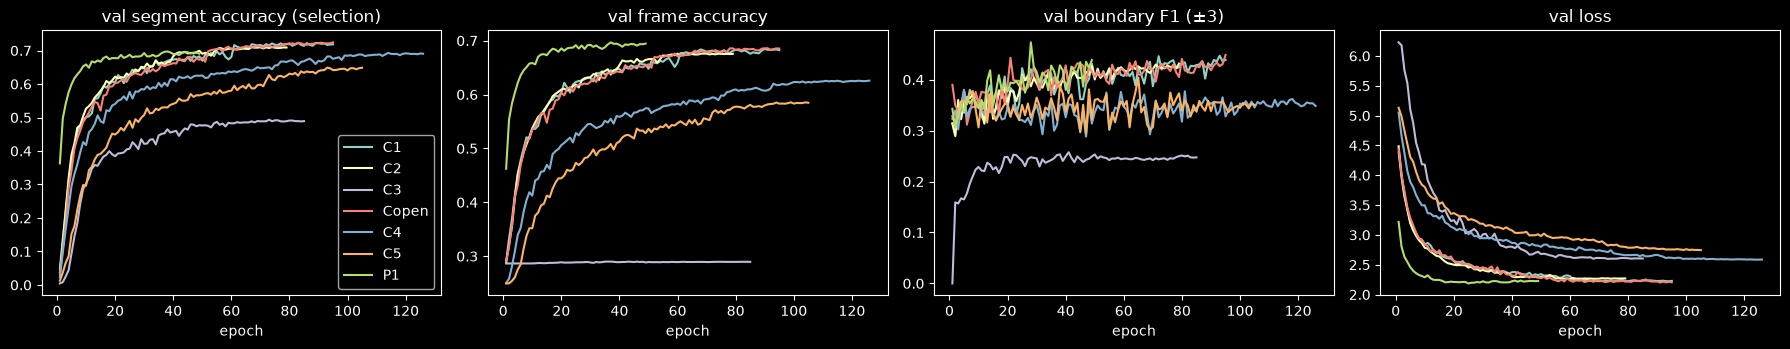

       epochs  best_seg_acc  best_epoch  frame_acc@best  boundary_f1@best
C1       95.0      0.723280        83.0        0.681985          0.427080
C2       79.0      0.710317        74.0        0.675670          0.422260
C3       85.0      0.493386        73.0        0.289480          0.244917
Copen    95.0      0.724296        95.0        0.685202          0.448362
C4      126.0      0.692857       114.0        0.624597          0.356795
C5      105.0      0.648942        93.0        0.582891          0.354993
P1       49.0      0.697090        38.0        0.694046          0.428289


In [9]:
# ============================================================
# Validation segment accuracy / frame accuracy / boundary F1 / loss
# ============================================================
curves = {}
for name in CONFIG["runs"]:
    rd = run_dir_for(name)
    if rd and (rd / "assets" / "history.json").exists():
        curves[name] = json.loads((rd / "assets" / "history.json").read_text())
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for name, h in curves.items():
    for ax, key in zip(axes, ("val_acc", "val_frame_acc", "val_boundary_f1", "val_loss")):
        ax.plot(np.arange(1, len(h[key]) + 1), h[key], label=name)
for ax, title in zip(axes, ("val segment accuracy (selection)", "val frame accuracy", "val boundary F1 (±3)", "val loss")):
    ax.set_title(title)
    ax.set_xlabel("epoch")
axes[0].legend()
fig.tight_layout()
fig.savefig(ASSETS / "learning_curves.png", dpi=110)
plt.show()
summary = pd.DataFrame({n: {"epochs": len(h["val_acc"]), "best_seg_acc": max(h["val_acc"]),
                            "best_epoch": int(np.argmax(h["val_acc"])) + 1,
                            "frame_acc@best": h["val_frame_acc"][int(np.argmax(h["val_acc"]))],
                            "boundary_f1@best": h["val_boundary_f1"][int(np.argmax(h["val_acc"]))]}
                        for n, h in curves.items()}).T
print(summary.to_string())

## 8. Canonical isolated evaluation

The same `sb-evaluate` every registry run gets: GISLR_Stratified `test.csv`,
per-class accuracy, the model read out at each clip's last frame. It puts
the continuous models on the existing leaderboard next to the isolated
ones (`gru_reg` 0.7517). Note that `sb-evaluate` subsamples clips longer
than 128 frames, as it does for every model. Copen scores 0 on its 20
held-out glosses by construction.

In [10]:
# ============================================================
# sb-evaluate every finished run (skips runs already canonical)
# ============================================================
from sb.mlops import registry as R
from sb.recognize.evaluate import evaluate_run

for name in CONFIG["runs"]:
    rd = run_dir_for(name)
    if rd is None or not (rd / "meta.json").exists():
        print(f"{name}: not trained yet")
        continue
    meta = R.load_meta(rd)
    if not meta["training"]["finished"]:
        print(f"{name}: still training ({meta['training']['epochs_trained']} epochs)")
        continue
    if meta["metrics"]["eval_status"] != "canonical":
        evaluate_run(rd, verbose=False)
        meta = R.load_meta(rd)
    m = meta["metrics"]
    print(f"{name:<6} run {rd.name}: canonical accuracy {m['overall_accuracy']:.4f} · macro {m['macro_accuracy']:.4f}")

C1     run 1790429419: canonical accuracy 0.7188 · macro 0.7163
C2     run 1790430959: canonical accuracy 0.7144 · macro 0.7122
C3     run 1790432253: canonical accuracy 0.3451 · macro 0.3448
Copen  run 1790433679: canonical accuracy 0.6696 · macro 0.6670
C4     run 1790435218: canonical accuracy 0.7339 · macro 0.7315
C5     run 1790435219: canonical accuracy 0.6795 · macro 0.6770
P1     run 1790416771: canonical accuracy 0.7260 · macro 0.7235
